# 06 — DistilBERT Fine-tuning para Clasificación de Currículos

**Modelo:** `distilbert-base-uncased` (backbone) + cabeza de clasificación Keras  
**Input:** `Resume_str` crudo — DistilBERT tiene su propio tokenizador WordPiece, no usa `clean_text`  
**Clases:** 24 categorías profesionales  
**Split:** 70/15/15 reproducido con `random_state=42` (misma semilla que notebooks anteriores)

## 0. Imports y configuración

In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'  # antes de cualquier import de TF o transformers
import math
import time
import json
import pickle
import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# ── TensorFlow / Keras ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── HuggingFace ─────────────────────────────────────────────────────────────
# Usamos TFAutoModel (backbone TF nativo) + cabeza Keras pura.
# Evitamos TFDistilBertForSequenceClassification por incompatibilidades
# conocidas con Keras 3.x en TF 2.20.
from transformers import AutoTokenizer, TFAutoModel


print(f'TensorFlow : {tf.__version__}')

import transformers
print(f'Transformers: {transformers.__version__}')

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs disponibles: {gpus}')

2026-05-16 22:57:37.112950: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-16 22:57:37.178242: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-16 22:57:38.299416: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.20.0
Transformers: 4.35.2
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Rutas y constantes

In [2]:
BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_PATH     = os.path.join(BASE_DIR, 'data', 'Resume.csv')
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')
METRICS_DIR   = os.path.join(ARTIFACTS_DIR, 'metrics')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')

os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

# ── Hiperparámetros ──────────────────────────────────────────────────────────
MODEL_NAME   = 'distilbert-base-uncased'
MAX_LEN      = 256        # tokens WordPiece — resumes son largos, 256 es balance razonable
BATCH_SIZE   = 16         # conservador para caber en GPU con backbone grande
EPOCHS       = 10         # con early stopping, rara vez llega al límite
LR           = 2e-5       # learning rate canónico para fine-tuning BERT
WARMUP_RATIO = 0.1        # 10% de los steps totales como warmup
RANDOM_STATE = 42

print(f'BASE_DIR : {BASE_DIR}')
print(f'DATA_PATH: {DATA_PATH}')
print(f'MAX_LEN  : {MAX_LEN}')
print(f'BATCH    : {BATCH_SIZE}')

BASE_DIR : /home/alejo/DeepLearning/miniproyecto3
DATA_PATH: /home/alejo/DeepLearning/miniproyecto3/data/Resume.csv
MAX_LEN  : 256
BATCH    : 16


## 2. Carga de artefactos y datos

In [3]:
# ── Label encoder (generado en notebook 01) ──────────────────────────────────
with open(os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)
print(f'Clases ({NUM_CLASSES}): {CLASS_NAMES}')

# ── Etiquetas ya codificadas ─────────────────────────────────────────────────
y_train_saved = np.load(os.path.join(ARTIFACTS_DIR, 'y_train.npy'))
y_val_saved   = np.load(os.path.join(ARTIFACTS_DIR, 'y_val.npy'))
y_test_saved  = np.load(os.path.join(ARTIFACTS_DIR, 'y_test.npy'))

print(f'y_train: {y_train_saved.shape}  y_val: {y_val_saved.shape}  y_test: {y_test_saved.shape}')

Clases (24): ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']
y_train: (1738,)  y_val: (373,)  y_test: (373,)


In [4]:
# ── Reproducir split de texto crudo con misma semilla ────────────────────────
# DistilBERT usa Resume_str crudo (NO clean_text).
# Reproducimos los índices con random_state=42 para alinearnos con y_*.npy.

df = pd.read_csv(DATA_PATH)
print(f'Dataset cargado: {df.shape}')

y_encoded = le.transform(df['Category'])
idx_all   = np.arange(len(df))

idx_train, idx_temp, _, y_temp = train_test_split(
    idx_all, y_encoded, test_size=0.30, stratify=y_encoded, random_state=RANDOM_STATE
)
idx_val, idx_test, _, _ = train_test_split(
    idx_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

# Texto crudo (sin preprocesamiento — DistilBERT tiene su tokenizador propio)
text_train = df['Resume_str'].iloc[idx_train].values
text_val   = df['Resume_str'].iloc[idx_val].values
text_test  = df['Resume_str'].iloc[idx_test].values

y_train = y_encoded[idx_train]
y_val   = y_encoded[idx_val]
y_test  = y_encoded[idx_test]

# Verificar consistencia con artefactos
assert np.array_equal(y_train, y_train_saved), 'ERROR: y_train no coincide con artefacto'
assert np.array_equal(y_val,   y_val_saved),   'ERROR: y_val no coincide con artefacto'
assert np.array_equal(y_test,  y_test_saved),  'ERROR: y_test no coincide con artefacto'
print('✓ Split reproducido correctamente — etiquetas alineadas con artefactos')
print(f'  train: {len(text_train)}  val: {len(text_val)}  test: {len(text_test)}')

Dataset cargado: (2484, 4)
✓ Split reproducido correctamente — etiquetas alineadas con artefactos
  train: 1738  val: 373  test: 373


## 3. Tokenización con DistilBERT WordPiece

> **Nota sobre MAX_LEN=256:** El EDA mostró una longitud media de 811 palabras (texto crudo). DistilBERT tiene un límite absoluto de 512 tokens WordPiece. MAX_LEN=256 trunca la mayoría de los currículos pero retiene el encabezado profesional — que suele concentrar las palabras clave de categoría. Es el balance entre cobertura semántica y costo computacional con 1738 muestras de entrenamiento.

In [5]:
print(f'Cargando tokenizador: {MODEL_NAME} ...')
bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('✓ Tokenizador cargado')

def tokenize_batch(texts, tokenizer, max_len):
    """Tokeniza una lista de textos y retorna input_ids + attention_mask como numpy arrays."""
    enc = tokenizer(
        list(texts),
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='np'       # numpy — compatible con tf.data sin overhead
    )
    return enc['input_ids'].astype(np.int32), enc['attention_mask'].astype(np.int32)

print('Tokenizando train ...')
X_train_ids, X_train_mask = tokenize_batch(text_train, bert_tokenizer, MAX_LEN)

print('Tokenizando val   ...')
X_val_ids,   X_val_mask   = tokenize_batch(text_val,   bert_tokenizer, MAX_LEN)

print('Tokenizando test  ...')
X_test_ids,  X_test_mask  = tokenize_batch(text_test,  bert_tokenizer, MAX_LEN)

print(f'\nShapes:')
print(f'  X_train_ids : {X_train_ids.shape}  X_train_mask : {X_train_mask.shape}')
print(f'  X_val_ids   : {X_val_ids.shape}    X_val_mask   : {X_val_mask.shape}')
print(f'  X_test_ids  : {X_test_ids.shape}   X_test_mask  : {X_test_mask.shape}')

Cargando tokenizador: distilbert-base-uncased ...
✓ Tokenizador cargado
Tokenizando train ...
Tokenizando val   ...
Tokenizando test  ...

Shapes:
  X_train_ids : (1738, 256)  X_train_mask : (1738, 256)
  X_val_ids   : (373, 256)    X_val_mask   : (373, 256)
  X_test_ids  : (373, 256)   X_test_mask  : (373, 256)


## 4. Pipelines `tf.data.Dataset`

In [6]:
def make_dataset(ids, mask, labels, batch_size, shuffle=False):
    """Construye un tf.data.Dataset con dos inputs (input_ids, attention_mask) y etiquetas."""
    ds = tf.data.Dataset.from_tensor_slices((
        {'input_ids': ids, 'attention_mask': mask},
        labels
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(labels), seed=RANDOM_STATE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

ds_train = make_dataset(X_train_ids, X_train_mask, y_train, BATCH_SIZE, shuffle=True)
ds_val   = make_dataset(X_val_ids,   X_val_mask,   y_val,   BATCH_SIZE, shuffle=False)
ds_test  = make_dataset(X_test_ids,  X_test_mask,  y_test,  BATCH_SIZE, shuffle=False)

print(f'ds_train batches: {len(ds_train)}')
print(f'ds_val   batches: {len(ds_val)}')
print(f'ds_test  batches: {len(ds_test)}')

# Sanity check de shapes
for x_batch, y_batch in ds_train.take(1):
    print(f'\nBatch shape — input_ids: {x_batch["input_ids"].shape}  labels: {y_batch.shape}')

I0000 00:00:1778990261.027822   10739 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


ds_train batches: 109
ds_val   batches: 24
ds_test  batches: 24

Batch shape — input_ids: (16, 256)  labels: (16,)


2026-05-16 22:57:41.920007: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 5. Arquitectura del modelo

### Decisión de implementación

Se usa **`TFAutoModel` (backbone) + cabeza de clasificación Keras pura** en lugar de `TFDistilBertForSequenceClassification`.  
Razón: `TFDistilBertForSequenceClassification` presenta incompatibilidades con Keras 3.x (el API `call()` interno conflictúa con el grafo de Keras 3 en TF 2.20), produciendo errores de compilación en `model.fit()`. El patrón backbone + cabeza custom es equivalente en capacidad, más estable, y totalmente compatible con la Functional API de Keras 3.

### Estrategia de fine-tuning

Se entrena el **backbone completo** (full fine-tuning) junto con la cabeza desde el inicio.  
Justificación: con solo 1738 muestras, el fine-tuning completo con learning rate bajo (2e-5) y warmup es estándar — los pesos preentrenados proveen regularización implícita.

In [8]:
import os
from huggingface_hub import hf_hub_download
from transformers import TFDistilBertModel, DistilBertConfig

print('Descargando config y pesos TF nativos...')

# Descargar tf_model.h5 directamente — evita la conversión PyTorch→TF que falla
weights_path = hf_hub_download(
    repo_id='distilbert-base-uncased',
    filename='tf_model.h5'
)
print(f'Pesos descargados en: {weights_path}')

# Construir modelo desde config y cargar pesos directamente
config   = DistilBertConfig.from_pretrained('distilbert-base-uncased')
backbone = TFDistilBertModel(config)

# Llamada dummy para inicializar pesos antes de cargar
import numpy as np
dummy_ids  = np.zeros((1, 10), dtype=np.int32)
dummy_mask = np.ones((1, 10),  dtype=np.int32)
_ = backbone(dummy_ids, attention_mask=dummy_mask)

# Cargar pesos .h5 directamente — sin pasar por transformers
backbone.load_weights(weights_path, by_name=True, skip_mismatch=True)
print('✓ Backbone cargado con pesos preentrenados')

# ── Functional API ───────────────────────────────────────────────────────────
input_ids      = keras.Input(shape=(MAX_LEN,), dtype='int32', name='input_ids')
attention_mask = keras.Input(shape=(MAX_LEN,), dtype='int32', name='attention_mask')

# Backbone — training=False en inferencia para desactivar dropout interno
bert_outputs = backbone(
    input_ids,
    attention_mask=attention_mask,
    training=False
)

# Token [CLS] (posición 0) — representación global de la secuencia
cls_output = bert_outputs.last_hidden_state[:, 0, :]   # (batch, 768)

# Cabeza de clasificación
x   = layers.Dropout(0.3)(cls_output)
x   = layers.Dense(256, activation='relu', name='dense_1')(x)
x   = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax', name='output')(x)

model = keras.Model(
    inputs=[input_ids, attention_mask],
    outputs=out,
    name='DistilBERT_Classifier'
)

model.summary()

Descargando config y pesos TF nativos...
Pesos descargados en: /home/alejo/.cache/huggingface/hub/models--distilbert-base-uncased/snapshots/12040accade4e8a0f71eabdb258fecc2e7e948be/tf_model.h5
✓ Backbone cargado con pesos preentrenados
Model: "DistilBERT_Classifier"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 tf_distil_bert_model_1 (TF  TFBaseModel

## 6. Optimizer con linear warmup

El learning rate sube linealmente desde 0 hasta `LR` durante los primeros `warmup_steps`, luego decae linealmente a 0. Esto es el schedule estándar para fine-tuning de Transformers — estabiliza el entrenamiento en las primeras épocas cuando los pesos de la cabeza están sin inicializar.

steps_per_epoch : 109
total_steps     : 1090
warmup_steps    : 109


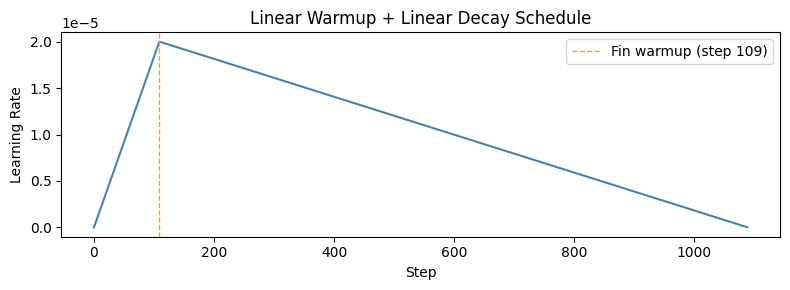

In [9]:
steps_per_epoch = math.ceil(len(y_train) / BATCH_SIZE)
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)

print(f'steps_per_epoch : {steps_per_epoch}')
print(f'total_steps     : {total_steps}')
print(f'warmup_steps    : {warmup_steps}')

class LinearWarmupSchedule(keras.optimizers.schedules.LearningRateSchedule):
    """Sube linealmente hasta peak_lr en warmup_steps, luego decae linealmente a 0."""
    def __init__(self, peak_lr, warmup_steps, total_steps):
        super().__init__()
        self.peak_lr      = float(peak_lr)
        self.warmup_steps = float(warmup_steps)
        self.total_steps  = float(total_steps)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.peak_lr * (step / tf.maximum(self.warmup_steps, 1.0))
        decay_lr  = self.peak_lr * tf.maximum(
            0.0,
            (self.total_steps - step) / tf.maximum(self.total_steps - self.warmup_steps, 1.0)
        )
        return tf.where(step < self.warmup_steps, warmup_lr, decay_lr)

    def get_config(self):
        return {
            'peak_lr'     : self.peak_lr,
            'warmup_steps': self.warmup_steps,
            'total_steps' : self.total_steps
        }

lr_schedule = LinearWarmupSchedule(
    peak_lr=LR,
    warmup_steps=warmup_steps,
    total_steps=total_steps
)

# Visualizar el schedule
lrs = [float(lr_schedule(s)) for s in range(total_steps)]
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(lrs, color='steelblue', lw=1.5)
ax.axvline(warmup_steps, color='orange', linestyle='--', lw=1, label=f'Fin warmup (step {warmup_steps})')
ax.set_xlabel('Step')
ax.set_ylabel('Learning Rate')
ax.set_title('Linear Warmup + Linear Decay Schedule')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Compilación y callbacks

In [10]:
optimizer = Adam(learning_rate=lr_schedule, clipnorm=1.0)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

MODEL_SAVE_PATH = os.path.join(MODELS_DIR, 'distilbert_classifier.keras')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,              # paciencia reducida — fine-tuning converge rápido
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
    # Nota: ReduceLROnPlateau NO se usa aquí porque ya tenemos un schedule
    # explícito. Combinarlo causaría conflicto entre el decay del schedule
    # y el factor del plateau.
]

print('✓ Modelo compilado')
print(f'  Parámetros totales    : {model.count_params():,}')
print(f'  Guardar mejor en      : {MODEL_SAVE_PATH}')

✓ Modelo compilado
  Parámetros totales    : 66,565,912
  Guardar mejor en      : /home/alejo/DeepLearning/miniproyecto3/models/distilbert_classifier.keras


## 8. Entrenamiento

In [11]:
print('Iniciando entrenamiento...')
print(f'  Epochs máx : {EPOCHS}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  MAX_LEN    : {MAX_LEN}')
print('-' * 50)

t0 = time.time()

history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - t0
print(f'\nEntrenamiento finalizado en {training_time:.1f}s ({training_time/60:.1f} min)')

Iniciando entrenamiento...
  Epochs máx : 10
  Batch size : 16
  MAX_LEN    : 256
--------------------------------------------------
Epoch 1/10


2026-05-16 23:00:37.580987: I external/local_xla/xla/service/service.cc:163] XLA service 0x740c144c6e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-16 23:00:37.581034: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-05-16 23:00:37.602984: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-16 23:00:37.650881: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
I0000 00:00:1778990437.744692   10822 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


109/109 [==============================] - ETA: 0s - loss: 3.1924 - accuracy: 0.0639
Epoch 1: val_loss improved from inf to 2.85399, saving model to /home/alejo/DeepLearning/miniproyecto3/models/distilbert_classifier.keras
109/109 [==============================] - 57s 376ms/step - loss: 3.1924 - accuracy: 0.0639 - val_loss: 2.8540 - val_accuracy: 0.2949
Epoch 2/10
109/109 [==============================] - ETA: 0s - loss: 1.8504 - accuracy: 0.5311
Epoch 2: val_loss improved from 2.85399 to 1.00344, saving model to /home/alejo/DeepLearning/miniproyecto3/models/distilbert_classifier.keras
109/109 [==============================] - 41s 373ms/step - loss: 1.8504 - accuracy: 0.5311 - val_loss: 1.0034 - val_accuracy: 0.7641
Epoch 3/10
109/109 [==============================] - ETA: 0s - loss: 0.8719 - accuracy: 0.7940
Epoch 3: val_loss improved from 1.00344 to 0.86770, saving model to /home/alejo/DeepLearning/miniproyecto3/models/distilbert_classifier.keras
109/109 [========================

## 9. Curvas de entrenamiento

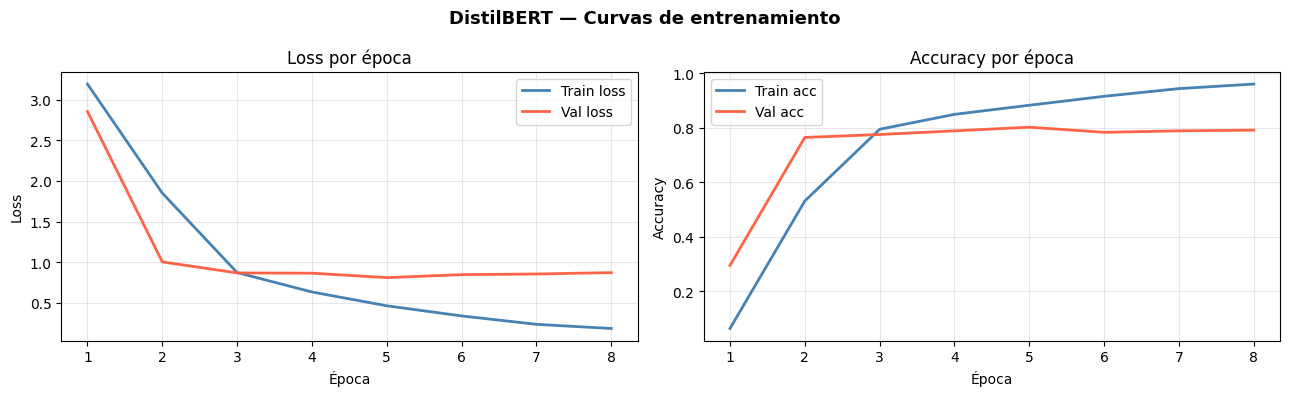

Mejor época (menor val_loss): 5
  val_loss     : 0.8101
  val_accuracy : 0.8016


In [12]:
hist = history.history
epochs_run = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(epochs_run, hist['loss'],     label='Train loss',  color='steelblue', lw=2)
axes[0].plot(epochs_run, hist['val_loss'], label='Val loss',    color='tomato',    lw=2)
axes[0].set_title('Loss por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_run, hist['accuracy'],     label='Train acc', color='steelblue', lw=2)
axes[1].plot(epochs_run, hist['val_accuracy'], label='Val acc',   color='tomato',    lw=2)
axes[1].set_title('Accuracy por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('DistilBERT — Curvas de entrenamiento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_epoch = int(np.argmin(hist['val_loss'])) + 1
print(f'Mejor época (menor val_loss): {best_epoch}')
print(f'  val_loss     : {hist["val_loss"][best_epoch-1]:.4f}')
print(f'  val_accuracy : {hist["val_accuracy"][best_epoch-1]:.4f}')

## 10. Predicciones en test

In [13]:
print('Generando predicciones en test...')
y_proba_test = model.predict(ds_test, verbose=1)   # (N, NUM_CLASSES)
y_pred_test  = np.argmax(y_proba_test, axis=1)

print(f'y_proba_test shape : {y_proba_test.shape}')
print(f'y_pred_test  shape : {y_pred_test.shape}')

# Verificar que las probabilidades sumen ~1.0
row_sums = y_proba_test.sum(axis=1)
print(f'Suma de probs por fila — min: {row_sums.min():.6f}  max: {row_sums.max():.6f}')

Generando predicciones en test...
24/24 [==============================] - 3s 103ms/step
y_proba_test shape : (373, 24)
y_pred_test  shape : (373,)
Suma de probs por fila — min: 1.000000  max: 1.000000


## 11. Métricas de evaluación

In [14]:
acc       = accuracy_score(y_test, y_pred_test)
prec_w    = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
rec_w     = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
f1_w      = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
roc_auc_w = roc_auc_score(y_test, y_proba_test, multi_class='ovr', average='weighted')
roc_auc_m = roc_auc_score(y_test, y_proba_test, multi_class='ovr', average='micro')

# Mean Average Precision
y_test_bin = label_binarize(y_test, classes=np.arange(NUM_CLASSES))
map_score  = average_precision_score(y_test_bin, y_proba_test, average='weighted')

print('=' * 55)
print('MÉTRICAS FINALES — DistilBERT (test set)')
print('=' * 55)
print(f'  Accuracy              : {acc:.4f}')
print(f'  Precision (weighted)  : {prec_w:.4f}')
print(f'  Recall (weighted)     : {rec_w:.4f}')
print(f'  F1 (weighted)         : {f1_w:.4f}')
print(f'  ROC-AUC (OvR weighted): {roc_auc_w:.4f}')
print(f'  ROC-AUC (micro)       : {roc_auc_m:.4f}')
print(f'  MAP (weighted)        : {map_score:.4f}')
print('=' * 55)

MÉTRICAS FINALES — DistilBERT (test set)
  Accuracy              : 0.8016
  Precision (weighted)  : 0.7850
  Recall (weighted)     : 0.8016
  F1 (weighted)         : 0.7899
  ROC-AUC (OvR weighted): 0.9746
  ROC-AUC (micro)       : 0.9806
  MAP (weighted)        : 0.8602


In [15]:
print('\nClassification Report:')
print(classification_report(
    y_test, y_pred_test,
    target_names=CLASS_NAMES,
    zero_division=0
))


Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       1.00      1.00      1.00        17
              ADVOCATE       0.88      0.82      0.85        17
           AGRICULTURE       0.56      0.50      0.53        10
               APPAREL       0.70      0.50      0.58        14
                  ARTS       0.50      0.38      0.43        16
            AUTOMOBILE       0.00      0.00      0.00         5
              AVIATION       0.75      0.83      0.79        18
               BANKING       0.80      0.67      0.73        18
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.85      0.94      0.89        18
                  CHEF       0.93      0.76      0.84        17
          CONSTRUCTION       1.00      1.00      1.00        17
            CONSULTANT       0.89      0.94      0.92        18
              DESIGNER       0.94      1.00      0.97        16
         DIGITA

## 12. Matrices de confusión

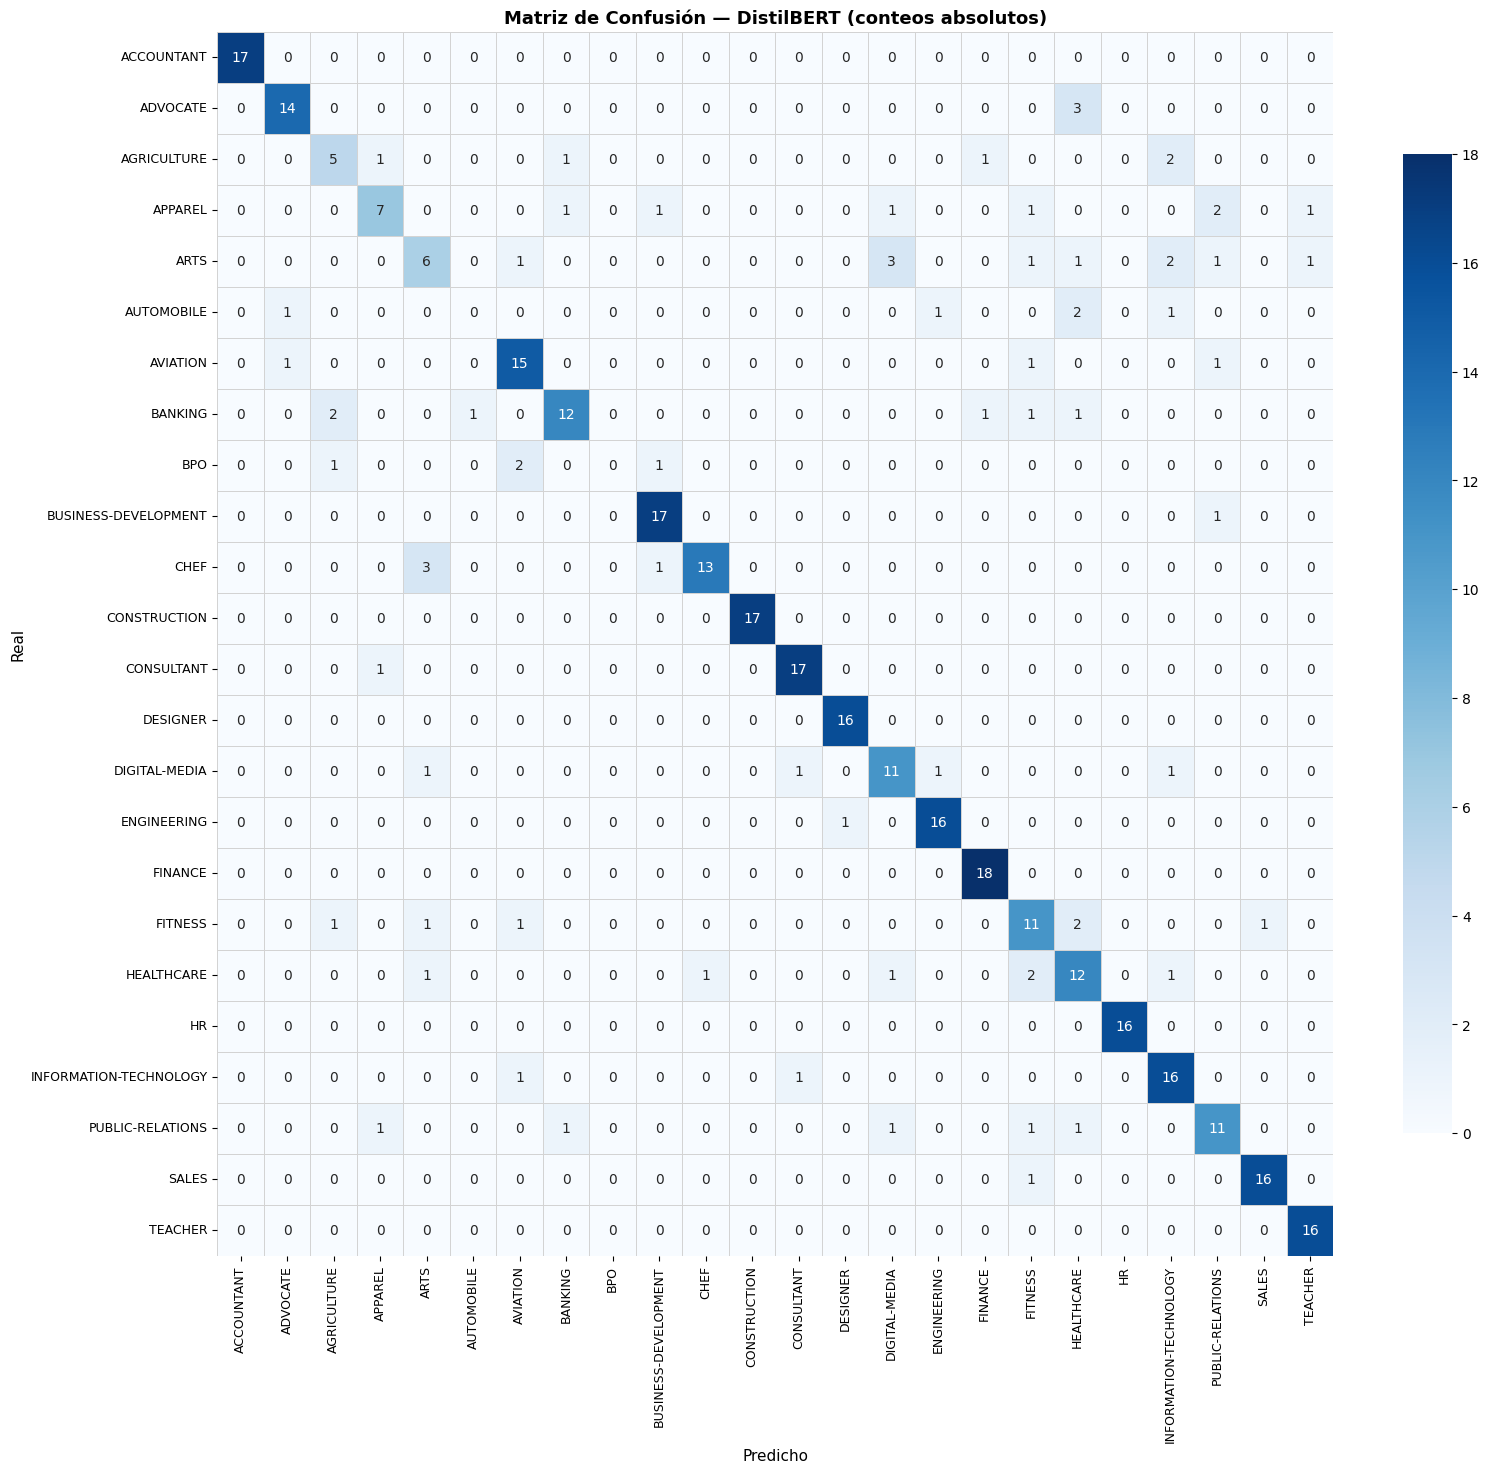

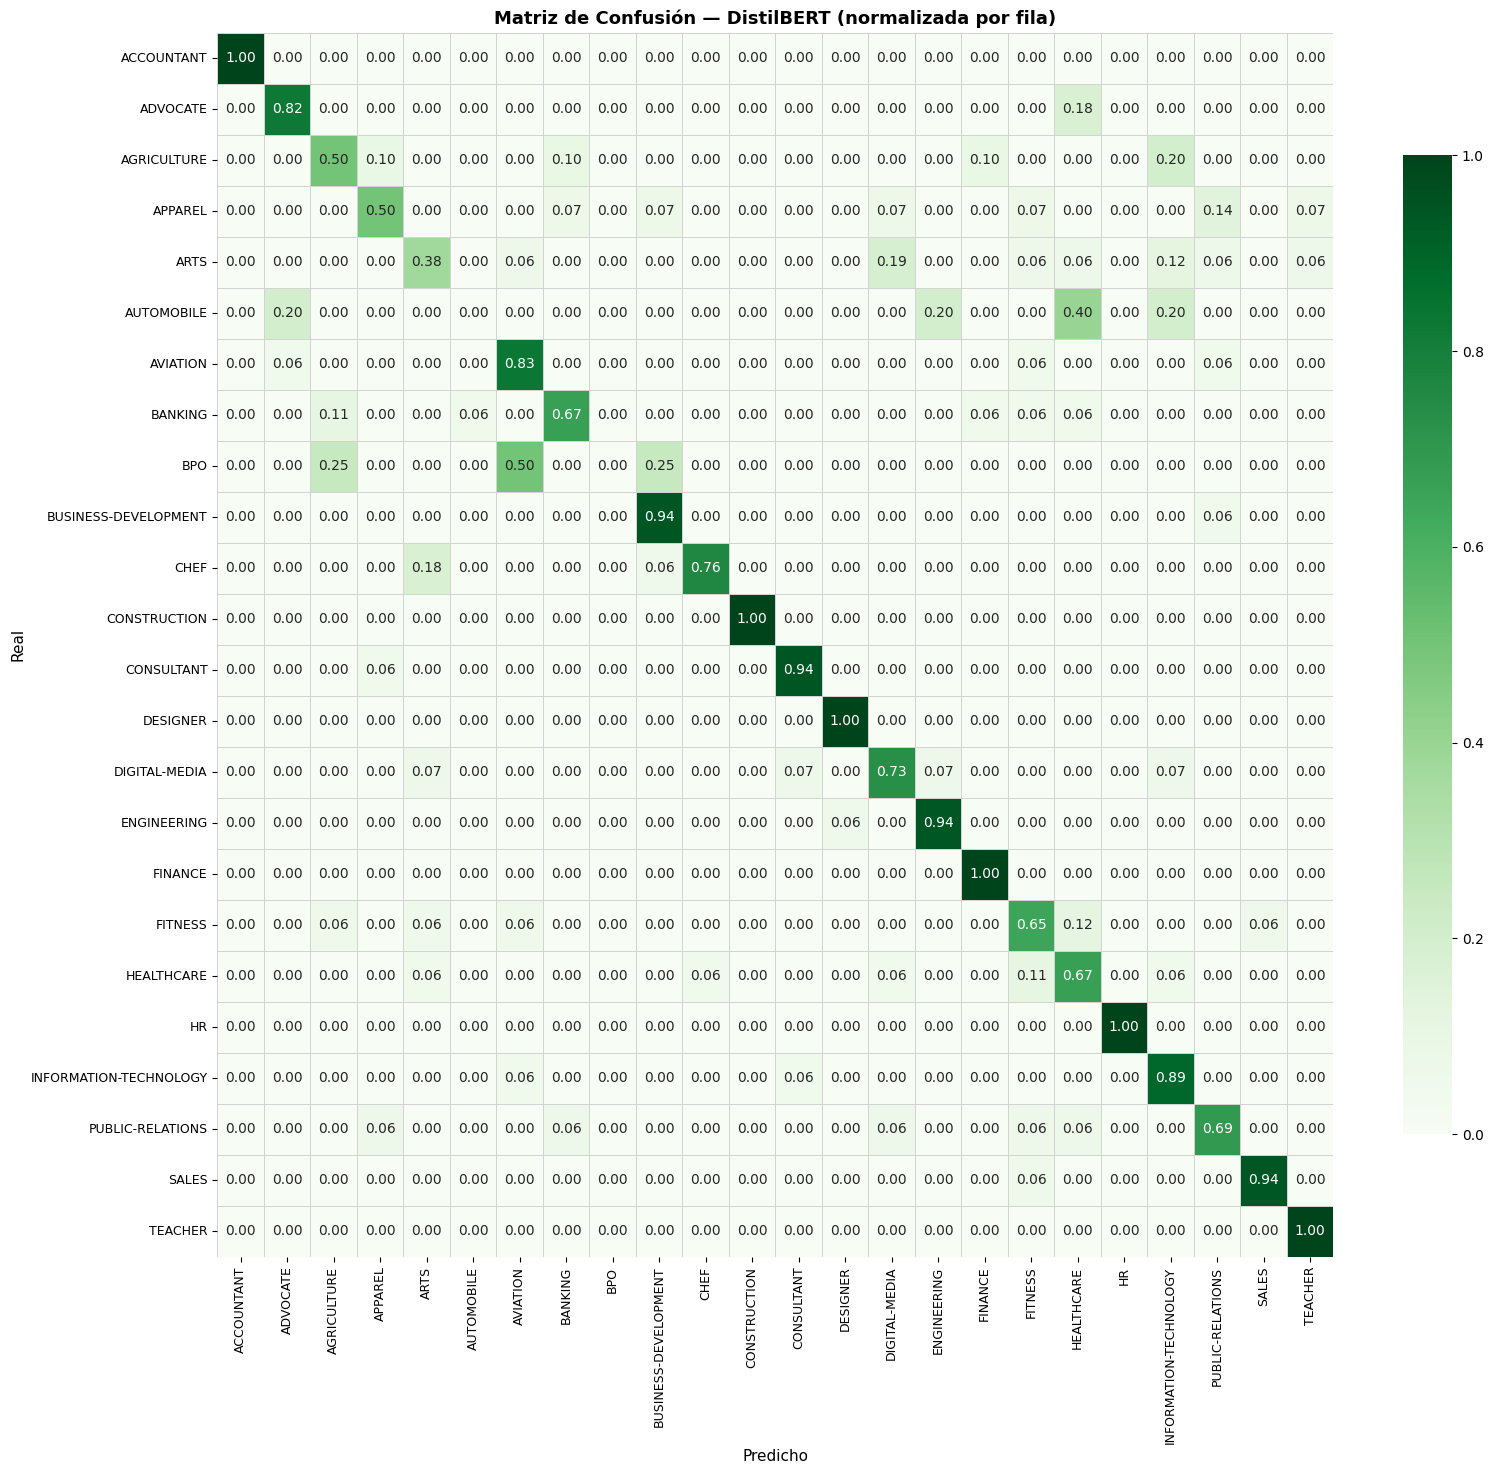

In [16]:
cm      = confusion_matrix(y_test, y_pred_test)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

cell_size = 0.75
fig_side  = max(12, NUM_CLASSES * cell_size)

# ── Figura 1: conteos absolutos ──────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(fig_side, fig_side))
sns.heatmap(cm, ax=ax1, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='lightgray', cbar_kws={'shrink': 0.8})
ax1.set_title('Matriz de Confusión — DistilBERT (conteos absolutos)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Predicho', fontsize=11)
ax1.set_ylabel('Real', fontsize=11)
ax1.tick_params(axis='x', rotation=90, labelsize=9)
ax1.tick_params(axis='y', rotation=0,  labelsize=9)
plt.subplots_adjust(bottom=0.2)
plt.show()

# ── Figura 2: normalizada por filas ─────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(fig_side, fig_side))
sns.heatmap(cm_norm, ax=ax2, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='lightgray', vmin=0, vmax=1,
            cbar_kws={'shrink': 0.8})
ax2.set_title('Matriz de Confusión — DistilBERT (normalizada por fila)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Predicho', fontsize=11)
ax2.set_ylabel('Real', fontsize=11)
ax2.tick_params(axis='x', rotation=90, labelsize=9)
ax2.tick_params(axis='y', rotation=0,  labelsize=9)
plt.subplots_adjust(bottom=0.2)
plt.show()

## 13. Curvas ROC por clase

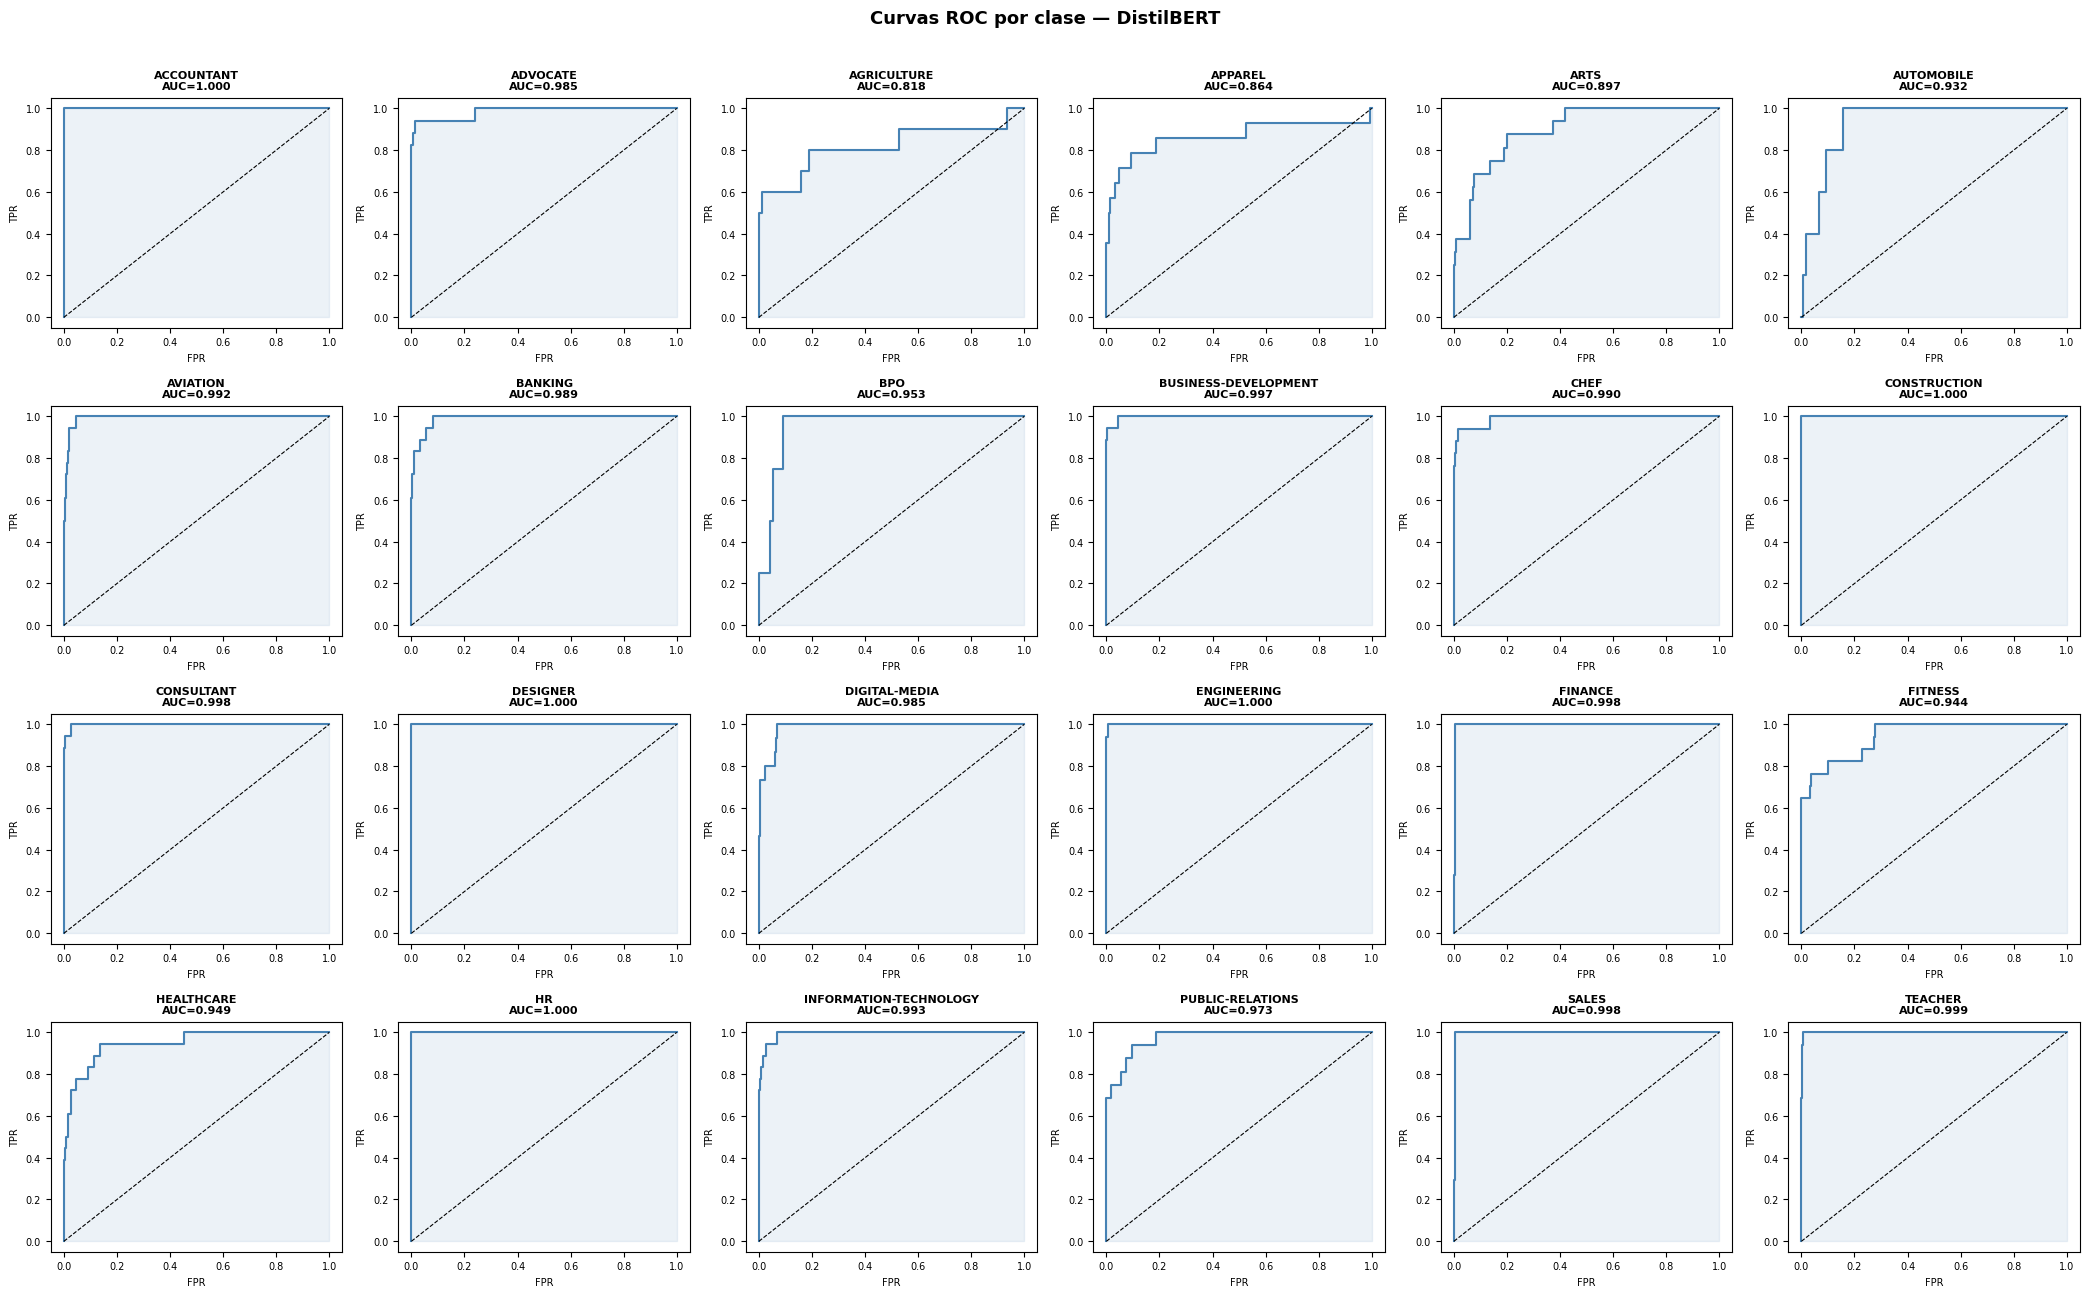

In [17]:
# Calcular ROC y PR por clase
fpr_dict     = {}
tpr_dict     = {}
roc_auc_dict = {}
prec_dict    = {}
rec_dict     = {}
pr_auc_dict  = {}

class_prevalence = y_test_bin.mean(axis=0)

for i in range(NUM_CLASSES):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], y_proba_test[:, i])
    roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

    prec_dict[i], rec_dict[i], _ = precision_recall_curve(y_test_bin[:, i], y_proba_test[:, i])
    pr_auc_dict[i] = auc(rec_dict[i], prec_dict[i])

# ── Subplots ROC ─────────────────────────────────────────────────────────────
n_cols = 6
n_rows = math.ceil(NUM_CLASSES / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.2))
for i in range(NUM_CLASSES):
    ax = axes.flatten()[i]
    ax.plot(fpr_dict[i], tpr_dict[i], color='steelblue', lw=1.5)
    ax.fill_between(fpr_dict[i], tpr_dict[i], alpha=0.1, color='steelblue')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(f'{CLASS_NAMES[i]}\nAUC={roc_auc_dict[i]:.3f}', fontsize=8, fontweight='bold')
    ax.set_xlabel('FPR', fontsize=7)
    ax.set_ylabel('TPR', fontsize=7)
    ax.tick_params(labelsize=7)

# Ocultar subplots vacíos
for j in range(NUM_CLASSES, n_rows * n_cols):
    axes.flatten()[j].set_visible(False)

plt.suptitle('Curvas ROC por clase — DistilBERT', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 14. Curvas Precision-Recall por clase

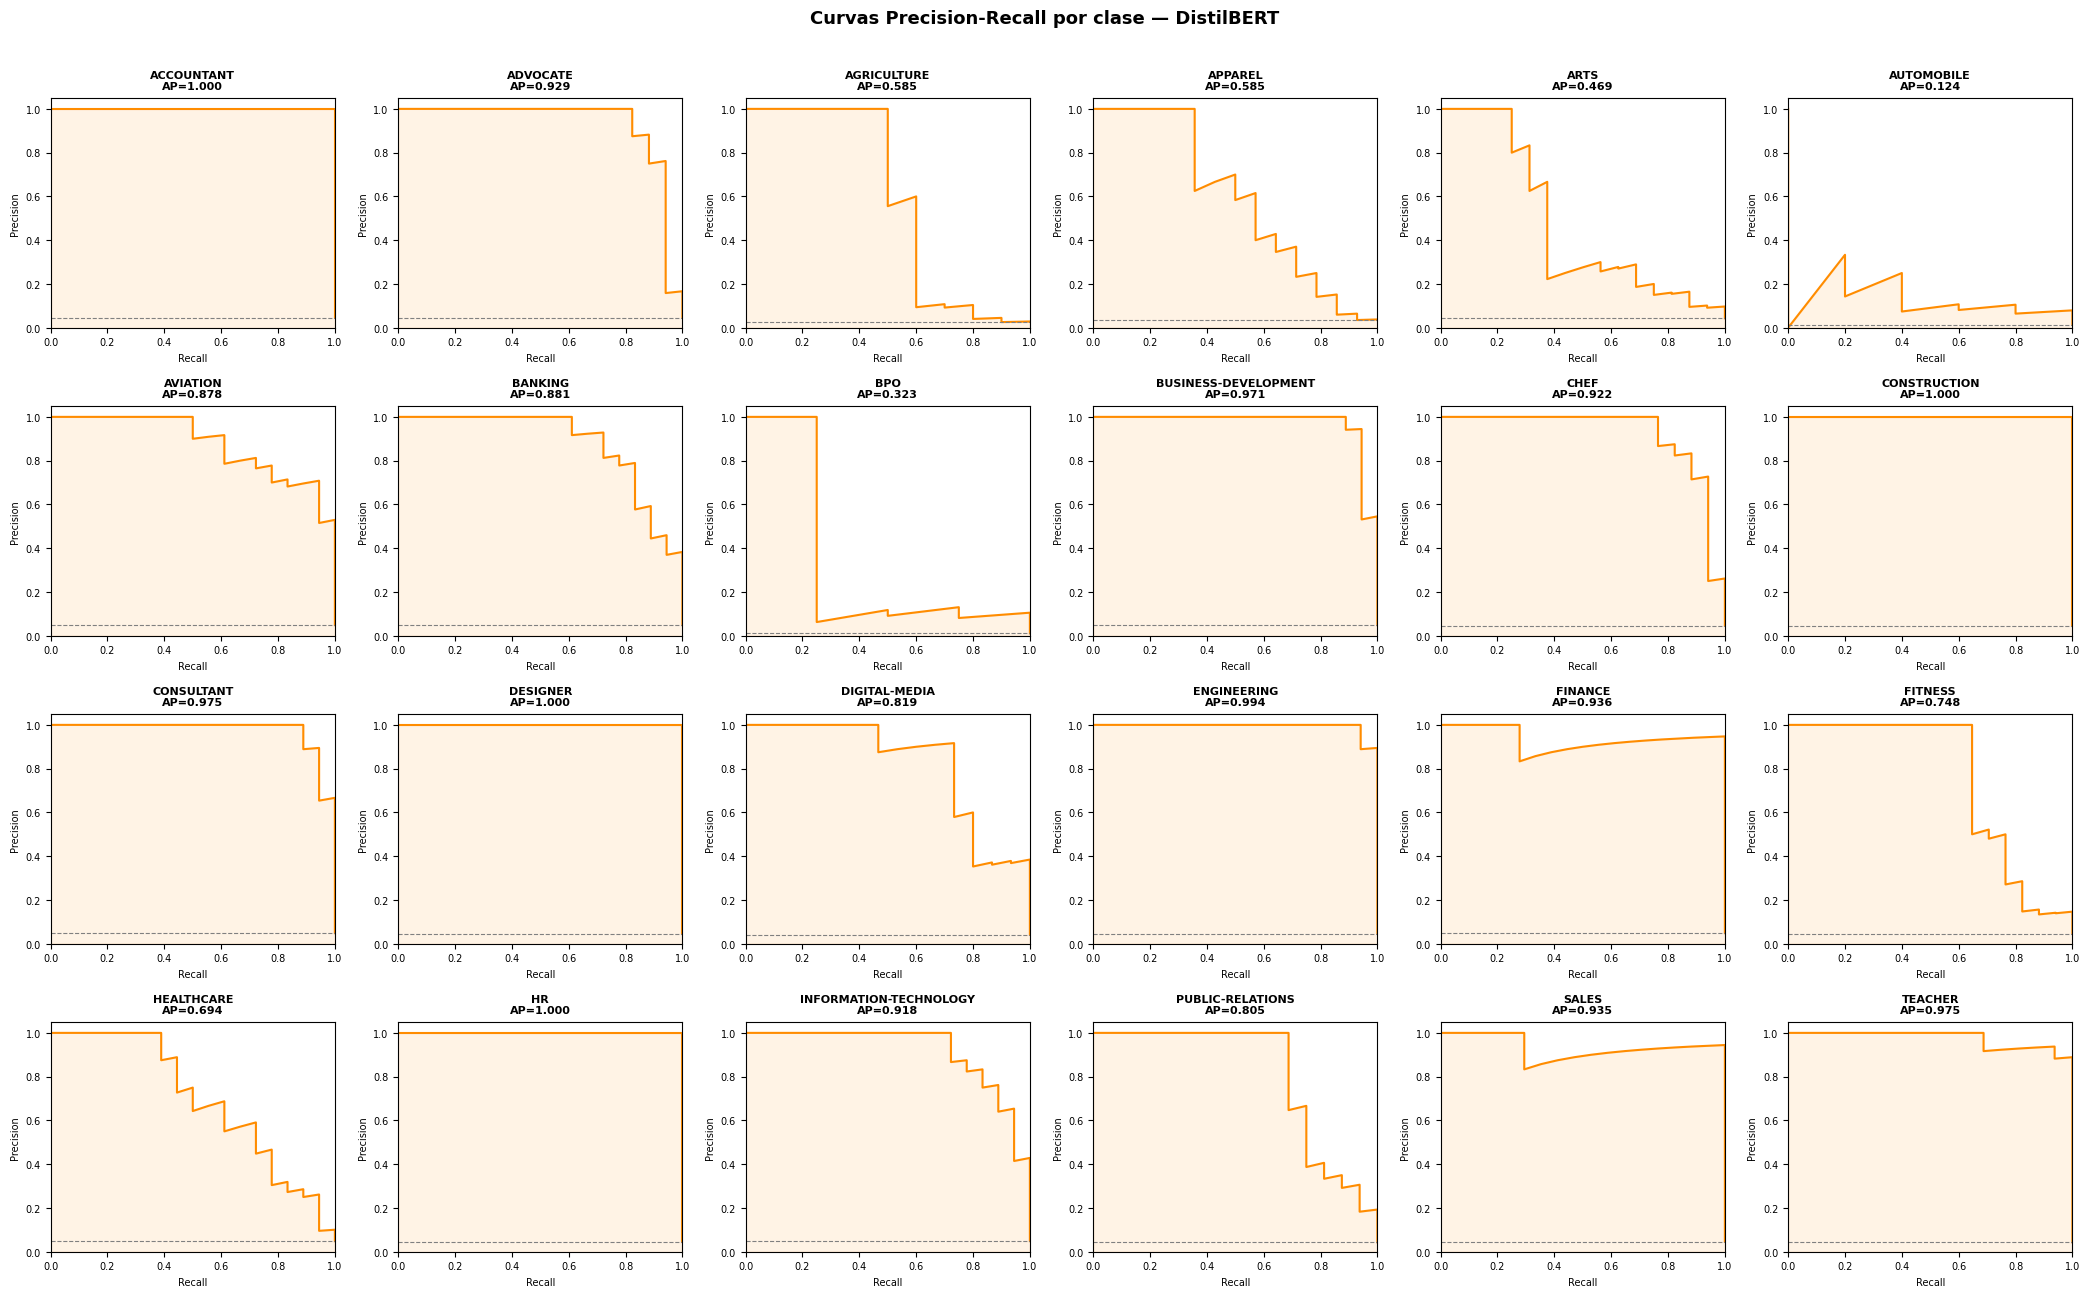

In [18]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.2))
for i in range(NUM_CLASSES):
    ax = axes.flatten()[i]
    ax.plot(rec_dict[i], prec_dict[i], color='darkorange', lw=1.5)
    ax.fill_between(rec_dict[i], prec_dict[i], alpha=0.1, color='darkorange')
    ax.axhline(class_prevalence[i], color='gray', linestyle='--', lw=0.8,
               label=f'Baseline={class_prevalence[i]:.2f}')
    ax.set_title(f'{CLASS_NAMES[i]}\nAP={pr_auc_dict[i]:.3f}', fontsize=8, fontweight='bold')
    ax.set_xlabel('Recall', fontsize=7)
    ax.set_ylabel('Precision', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

for j in range(NUM_CLASSES, n_rows * n_cols):
    axes.flatten()[j].set_visible(False)

plt.suptitle('Curvas Precision-Recall por clase — DistilBERT', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 15. Guardado de métricas

In [19]:
# Per-class metrics
per_class = {}
report    = classification_report(y_test, y_pred_test, target_names=CLASS_NAMES,
                                  zero_division=0, output_dict=True)
for i, cls in enumerate(CLASS_NAMES):
    per_class[cls] = {
        'precision': round(report[cls]['precision'], 4),
        'recall'   : round(report[cls]['recall'],    4),
        'f1'       : round(report[cls]['f1-score'],  4),
        'support'  : int(report[cls]['support']),
        'roc_auc'  : round(float(roc_auc_dict[i]),  4),
        'pr_auc'   : round(float(pr_auc_dict[i]),   4),
    }

metrics_dict = {
    'model_name'            : 'DistilBERT fine-tuned',
    'timestamp'             : datetime.datetime.now().isoformat(),
    'hyperparameters'       : {
        'backbone'          : MODEL_NAME,
        'max_len'           : MAX_LEN,
        'batch_size'        : BATCH_SIZE,
        'epochs_max'        : EPOCHS,
        'epochs_run'        : len(hist['loss']),
        'best_epoch'        : best_epoch,
        'learning_rate_peak': LR,
        'warmup_ratio'      : WARMUP_RATIO,
        'warmup_steps'      : warmup_steps,
        'total_steps'       : total_steps,
        'optimizer'         : 'Adam + LinearWarmup',
        'clipnorm'          : 1.0,
        'fine_tuning'       : 'full',
        'head_dropout'      : 0.3,
        'head_dense_units'  : 256,
    },
    'metrics'               : {
        'accuracy'              : round(float(acc),       4),
        'precision_weighted'    : round(float(prec_w),    4),
        'recall_weighted'       : round(float(rec_w),     4),
        'f1_weighted'           : round(float(f1_w),      4),
        'roc_auc_ovr_weighted'  : round(float(roc_auc_w), 4),
        'roc_auc_micro'         : round(float(roc_auc_m), 4),
        'mean_average_precision': round(float(map_score), 4),
    },
    'per_class'             : per_class,
    'training_time_seconds' : round(training_time, 1),
    'data_sizes'            : {'train': len(y_train), 'val': len(y_val), 'test': len(y_test)},
}

metrics_path = os.path.join(METRICS_DIR, 'distilbert_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=2)

print(f'✓ Métricas guardadas en: {metrics_path}')
print(f'\nResumen:')
for k, v in metrics_dict['metrics'].items():
    print(f'  {k:<30}: {v}')

✓ Métricas guardadas en: /home/alejo/DeepLearning/miniproyecto3/artifacts/metrics/distilbert_metrics.json

Resumen:
  accuracy                      : 0.8016
  precision_weighted            : 0.785
  recall_weighted               : 0.8016
  f1_weighted                   : 0.7899
  roc_auc_ovr_weighted          : 0.9746
  roc_auc_micro                 : 0.9806
  mean_average_precision        : 0.8602
